In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configurar estilo - versão compatível
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Definir paleta de cores manualmente
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

In [23]:
df_degradation = pd.read_csv("degradation_results.csv")
df_explanation = pd.read_csv("explanation_results.csv")

In [24]:
df_degradation.head()

,iteration,n_features,train_loss,val_loss,test_loss,n_epochs
0,1,1057,0.005936,0.008069,0.008201,44
1,2,951,0.008042,0.005566,0.005563,32
2,3,855,0.007786,0.010940,0.011110,28
3,4,769,0.004464,0.005535,0.005686,66
4,5,692,0.007616,0.009753,0.009837,27


In [25]:
df_explanation.head()

,iteration,n_features,features_selected,original_indices,test_loss,shap_explanation,positive_fidelity,negative_fidelity
0,1,951,"['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.008201,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",11.462289,1.373890
1,2,855,"['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.005563,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",24.885717,1.182231
2,3,769,"['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.011110,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",16.829027,0.984434
3,4,692,"['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.005686,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",20.830071,1.272168
4,5,622,"['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.009837,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",31.157011,1.718943


In [26]:
df_degradation.info()
df_explanation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   iteration   36 non-null     int64  
 1   n_features  36 non-null     int64  
 2   train_loss  36 non-null     float64
 3   val_loss    36 non-null     float64
 4   test_loss   36 non-null     float64
 5   n_epochs    36 non-null     int64  
dtypes: float64(3), int64(3)
memory usage: 1.8 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iteration          36 non-null     int64  
 1   n_features         36 non-null     int64  
 2   features_selected  36 non-null     object 
 3   original_indices   36 non-null     object 
 4   test_loss          36 non-null     float64
 5   shap_explanation   36 non-null     object 
 6   positive_fidelity  36 non-nul

In [27]:
# Primeiro, vamos verificar as colunas disponíveis
print("Colunas em df_explanation:")
print(df_explanation.columns.tolist())
print("\nPrimeiras linhas:")
print(df_explanation.head())

print("\nColunas em df_degradation:")
print(df_degradation.columns.tolist())
print("\nPrimeiras linhas:")
print(df_degradation.head())

Colunas em df_explanation:
['iteration', 'n_features', 'features_selected', 'original_indices', 'test_loss', 'shap_explanation', 'positive_fidelity', 'negative_fidelity']

Primeiras linhas:
   iteration  n_features                                  features_selected  \
0          1         951  ['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...   
1          2         855  ['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...   
2          3         769  ['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...   
3          4         692  ['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...   
4          5         622  ['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDi...   

                                    original_indices  test_loss  \
0  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   0.008201   
1  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   0.005563   
2  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   0.011110   
3  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...   0.005686   


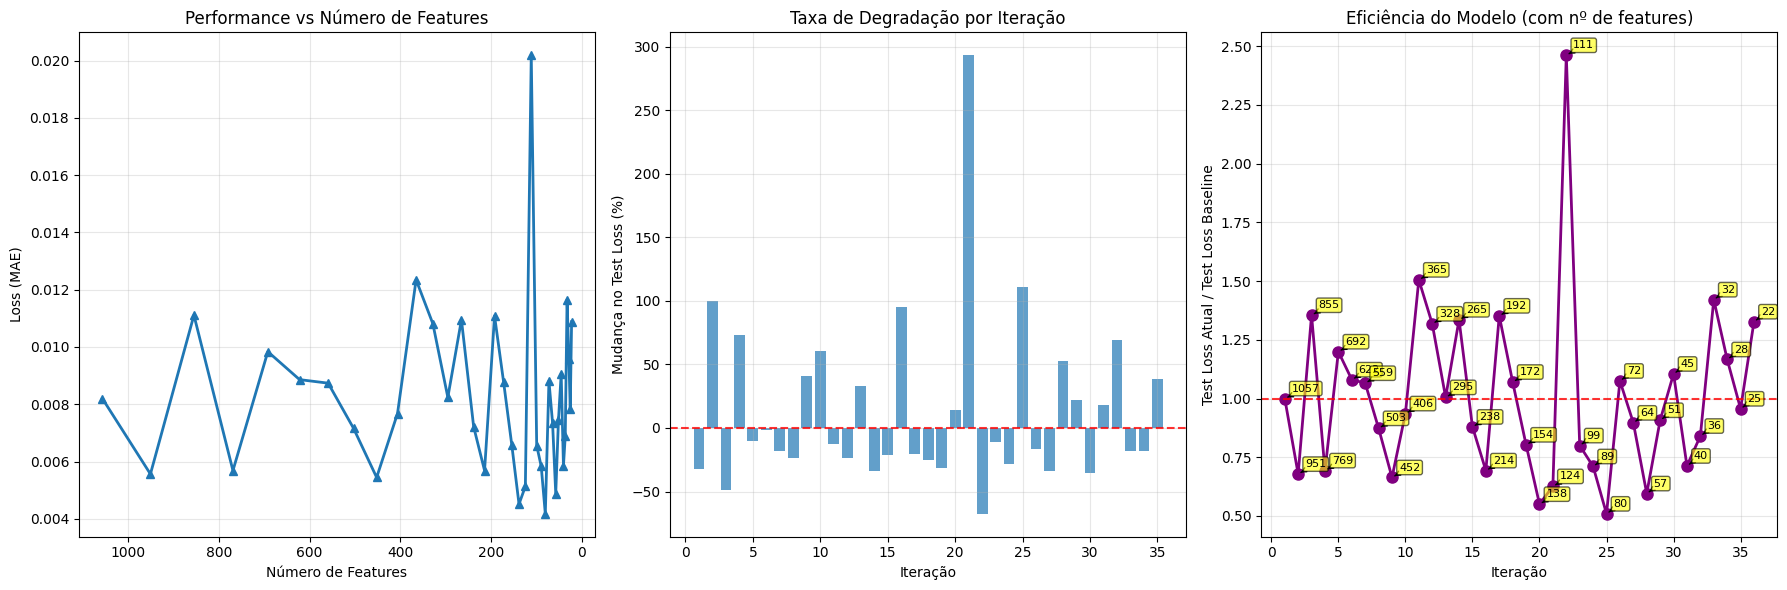

In [28]:
# 1. ANÁLISE DE PERFORMANCE VS NÚMERO DE FEATURES
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Evolução das Losses
axes[0].plot(df_degradation['n_features'], df_degradation['test_loss'], '^-', label='Test Loss', linewidth=2, markersize=6)
axes[0].set_xlabel('Número de Features')
axes[0].set_ylabel('Loss (MAE)')
axes[0].set_title('Performance vs Número de Features')
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()  # Inverter eixo X para mostrar degradação

# Plot 2: Taxa de Degradação
degradation_rate = df_degradation['test_loss'].pct_change() * 100
axes[1].bar(range(1, len(degradation_rate)), degradation_rate[1:], alpha=0.7)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Mudança no Test Loss (%)')
axes[1].set_title('Taxa de Degradação por Iteração')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.8)

# Plot 3: Eficiência (Performance por Feature) com anotações em todos os pontos
efficiency = df_degradation['test_loss'] / df_degradation['test_loss'][0]
axes[2].plot(df_degradation['iteration'], efficiency, 'o-', color='purple', linewidth=2, markersize=8)
axes[2].axhline(y=1, color='red', linestyle='--', alpha=0.8)

# Adicionar anotações com o número de features em TODOS os pontos
for i, (iter_val, eff_val, n_feat) in enumerate(zip(df_degradation['iteration'], efficiency, df_degradation['n_features'])):
    axes[2].annotate(f'{n_feat}', 
                    xy=(iter_val, eff_val), 
                    xytext=(5, 5), 
                    textcoords='offset points',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.6),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

axes[2].set_xlabel('Iteração')
axes[2].set_ylabel('Test Loss Atual / Test Loss Baseline')
axes[2].set_title('Eficiência do Modelo (com nº de features)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

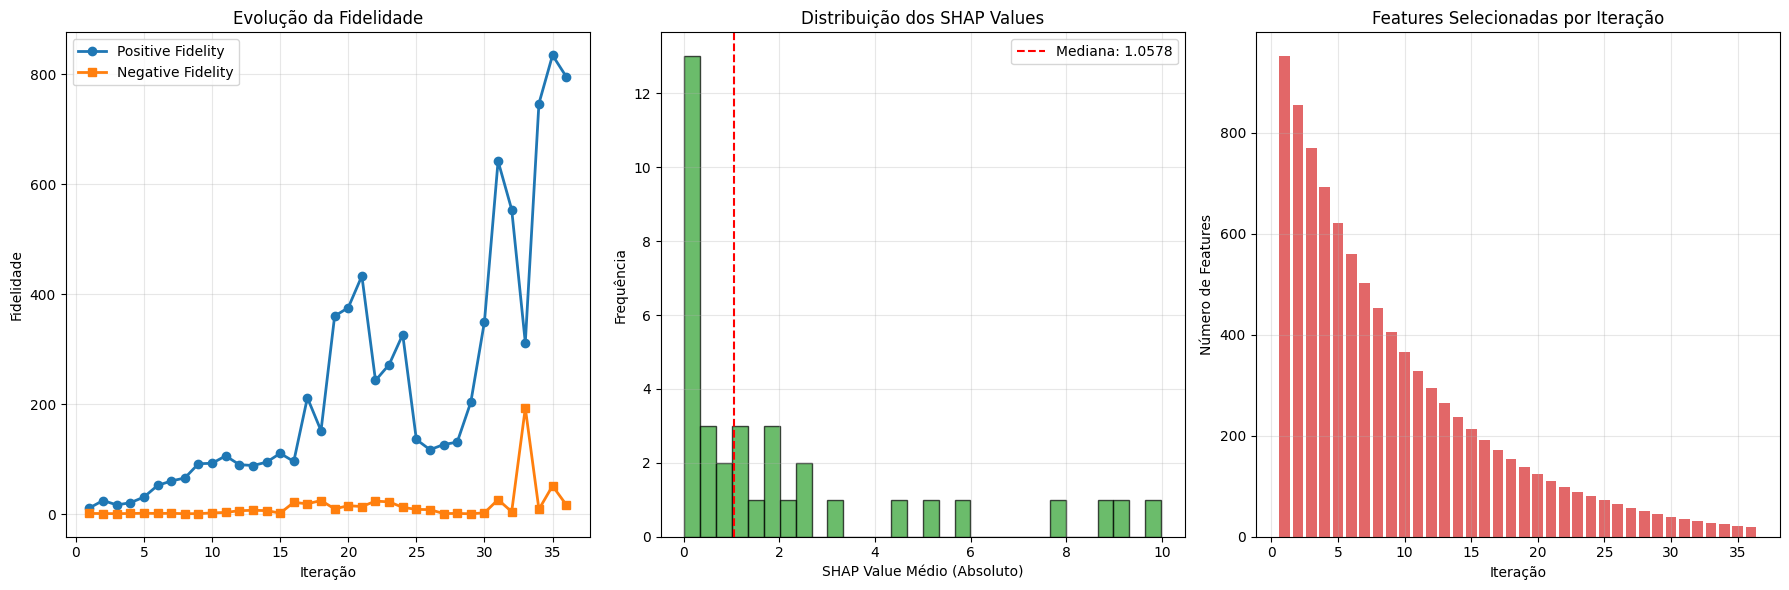

In [29]:
# 2. ANÁLISE DOS DADOS DE EXPLICAÇÃO (SHAP E FIDELIDADE)
import ast

# Primeiro, vamos processar os dados SHAP que estão como strings de listas
df_explanation['shap_values'] = df_explanation['shap_explanation'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_explanation['mean_shap_abs'] = df_explanation['shap_values'].apply(lambda x: np.mean(np.abs(x)))
df_explanation['mean_shap'] = df_explanation['shap_values'].apply(lambda x: np.mean(x))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Evolução das métricas de fidelidade
axes[0].plot(df_explanation['iteration'], df_explanation['positive_fidelity'], 'o-', 
             label='Positive Fidelity', linewidth=2, markersize=6, color=colors[0])
axes[0].plot(df_explanation['iteration'], df_explanation['negative_fidelity'], 's-', 
             label='Negative Fidelity', linewidth=2, markersize=6, color=colors[1])
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Fidelidade')
axes[0].set_title('Evolução da Fidelidade')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribuição dos SHAP values médios (valor absoluto)
axes[1].hist(df_explanation['mean_shap_abs'], bins=30, alpha=0.7, 
             edgecolor='black', color=colors[2])
axes[1].set_xlabel('SHAP Value Médio (Absoluto)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos SHAP Values')
axes[1].axvline(df_explanation['mean_shap_abs'].median(), color='red', 
                linestyle='--', label=f'Mediana: {df_explanation["mean_shap_abs"].median():.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Número de features por iteração
axes[2].bar(df_explanation['iteration'], df_explanation['n_features'], 
            alpha=0.7, color=colors[3])
axes[2].set_xlabel('Iteração')
axes[2].set_ylabel('Número de Features')
axes[2].set_title('Features Selecionadas por Iteração')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

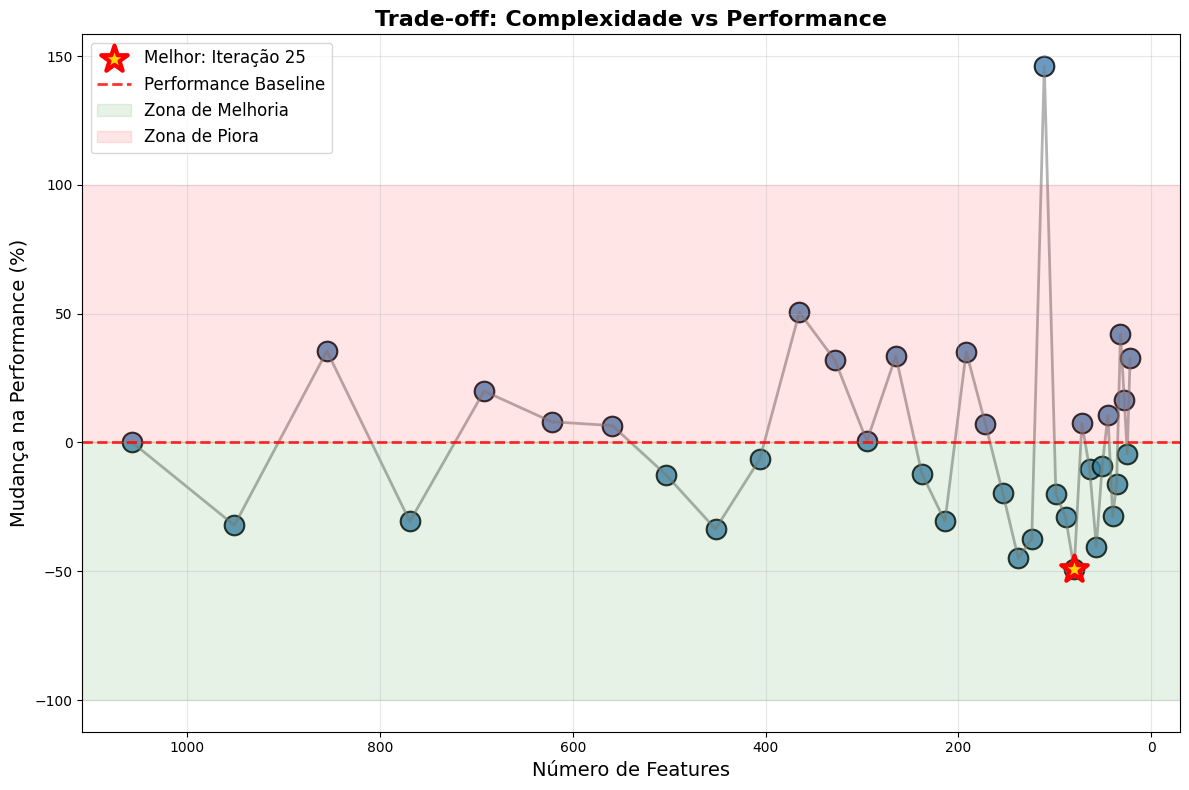

In [45]:
# ...existing code...

# 6. ANÁLISE DE TRADE-OFF SIMPLIFICADA
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Calcular mudança de performance
performance_change = (df_degradation['test_loss'] - df_degradation['test_loss'].iloc[0]) / df_degradation['test_loss'].iloc[0] * 100

# Plot principal: Número de features vs Performance (sem gradiente)
scatter = ax.scatter(df_degradation['n_features'], performance_change, 
                    s=200, alpha=0.8, color='steelblue', 
                    edgecolors='black', linewidth=1.5)

# Conectar pontos com linha
ax.plot(df_degradation['n_features'], performance_change, '-', 
        color='gray', alpha=0.6, linewidth=2, zorder=1)

# Destacar melhor iteração
best_iter_idx = df_explanation['test_loss'].idxmin()
best_n_feat = df_degradation.loc[best_iter_idx, 'n_features']
best_perf = performance_change.iloc[best_iter_idx]
best_iter_num = df_degradation.loc[best_iter_idx, 'iteration']

ax.scatter(best_n_feat, best_perf, s=400, color='gold', 
          edgecolor='red', linewidth=3, zorder=10, marker='*',
          label=f'Melhor: Iteração {int(best_iter_num)}')

# Linha de referência (sem mudança de performance)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.8, linewidth=2, 
          label='Performance Baseline')

# Apenas duas zonas: Melhoria e Piora
ax.axhspan(-100, 0, alpha=0.1, color='green', label='Zona de Melhoria')
ax.axhspan(0, 100, alpha=0.1, color='red', label='Zona de Piora')

# Inverter eixo X
ax.invert_xaxis()

ax.set_xlabel('Número de Features', fontsize=14)
ax.set_ylabel('Mudança na Performance (%)', fontsize=14)
ax.set_title('Trade-off: Complexidade vs Performance', 
            fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# ...existing code...